# ExportForSpatialData to SpatialData

The counterpart of `test-adapter-to-viewer.ipynb`. That one checks the per-cell table, comparing
the `ExportToSpreadsheet` CSVs against the `ExportToAnnData` `.h5ad` and drawing cell and nucleus
centres as points. This one checks what `ExportForSpatialData` adds: the pixels. Segmentation masks
instead of centre points, and one coordinate system per field of view, assembled into a
`SpatialData` object by `cell_painting_io.read_cellprofiler_export`.

Input:
* one plate folder of an export, holding `images/`, `labels/` and `tables/`

Process:
* read the folder into a `SpatialData` object, driven only by the manifest in the table's `uns`
* check every label array against the table rows that claim to annotate it
* view one field, its channels and its masks, in napari
* colour cells by a measurement, which is the join used rather than asserted
* confirm the table is the same one `ExportToAnnData` writes

The reader lives in [cell-painting-io](https://github.com/scverse/cell-painting-io), not here,
because that repo already assembles SpatialData objects for Cell Painting data from the gallery.
This notebook needs its own environment, since the reader requires Python 3.12 and this repo runs
on 3.10:

```bash
uv venv --python 3.12 .venv-spatial
VIRTUAL_ENV=.venv-spatial uv pip install spatialdata spatialdata-plot napari-spatialdata "napari[pyqt6]" ipykernel
VIRTUAL_ENV=.venv-spatial uv pip install -e ../cell-painting-io
```

In [1]:
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import spatialdata_plot  # noqa: F401  registers the .pl accessor on SpatialData

from cell_painting_io import cellprofiler_export_plates, read_cellprofiler_export

PLATE = "Testrun_cp2sd_2sd_export/plate"
CHANNEL = "DNA"
# The same field test-adapter-to-viewer.ipynb opens. Picking by file name rather than taking the
# first field, which in this run holds three cells and shows nothing.
IMAGE = "r02c04f01ch1.tiff"


def fields(sdata):
    """The field-of-view keys, which are also the coordinate system names."""
    return sorted(sdata.coordinate_systems)


def image_name(sdata, field):
    return f"{field}_image"


def label_names(sdata, field):
    """{object name: element name} for one field, e.g. {"Cells": "A02_03_img1__Cells"}."""
    return {name.split("__", 1)[1]: name for name in sdata.labels if name.startswith(f"{field}__")}


def rows_of(sdata, field, obj="Cells"):
    """The table rows annotating one field's labels element, in label order."""
    table = sdata.tables["cells"]
    wanted = f"{field}__{obj}"
    return table[table.obs["region_key"].astype(str) == wanted]


def field_of_image(sdata, filename, column="FileName_DNA"):
    """The field key whose image set loaded `filename`.

    The exporter names fields from Metadata tags, so the key says nothing about which file it came
    from. The mapping is in the provenance the table carries: one entry per image set in
    `uns["cellprofiler"]["image"]`, holding every `FileName_*` and `PathName_*` column.
    """
    table = sdata.tables["cells"]
    images = pd.DataFrame(table.uns["cellprofiler"]["image"]).set_index("ImageNumber")
    matching = images.index[images[column].eq(filename)]
    if len(matching) != 1:
        raise ValueError(f"{filename} matches {len(matching)} image sets, expected one")
    rows = table.obs.loc[table.obs["ImageNumber"].astype(int).eq(int(matching[0]))]
    return str(rows["region_key"].iloc[0]).rsplit("__", 1)[0]


def field_census(sdata, obj="Cells"):
    """One row per field: its image file and how many objects it has.

    Worth looking at before picking a field to show. Fields differ a lot in density, and the first
    one alphabetically is not usually the interesting one.
    """
    table = sdata.tables["cells"]
    images = pd.DataFrame(table.uns["cellprofiler"]["image"]).set_index("ImageNumber")
    out = []
    for field in fields(sdata):
        rows = rows_of(sdata, field, obj)
        image_number = int(rows.obs["ImageNumber"].iloc[0]) if rows.n_obs else None
        out.append({"field": field,
                    "file": images.loc[image_number, "FileName_DNA"] if image_number else "",
                    obj.lower(): rows.n_obs})
    return pd.DataFrame(out).set_index("field")


def join_report(sdata):
    """One row per labels element: do its integers and its table rows agree?

    This is the invariant the whole export rests on. Every non-zero integer in an annotated mask
    must have exactly one row, and every row must point at an integer in that mask. A mismatch
    means the masks and the measurements describe different objects, which no amount of downstream
    analysis would make obvious.

    `annotated` is False for a mask no row points at, which is not a fault: the table is one row
    per cell with the nucleus folded in, so only the base object is annotated. `agree` is left
    empty for those, since there is nothing to agree with.
    """
    out = []
    for name in sorted(sdata.labels):
        field, obj = name.split("__", 1)
        in_mask = set(np.unique(np.asarray(sdata.labels[name])).tolist()) - {0}
        rows = rows_of(sdata, field, obj)
        in_table = set(rows.obs["label_id"].astype(int).tolist())
        out.append({"element": name, "objects_in_mask": len(in_mask), "rows_in_table": len(rows),
                    "annotated": len(rows) > 0,
                    "agree": (in_mask == in_table) if rows.n_obs else pd.NA,
                    "only_in_mask": len(in_mask - in_table), "only_in_table": len(in_table - in_mask)})
    return pd.DataFrame(out).set_index("element")


def feature_map(sdata, field, feature, obj="Cells"):
    """The labels array with each object replaced by its value of `feature`, background as NaN.

    Painting a measurement back onto the pixels it came from uses the join rather than asserting
    it. If `region_key` or `label_id` were wrong, a gradient that should follow cell size would
    come out scrambled, which is visible at a glance in a way a passing assertion is not.
    """
    rows = rows_of(sdata, field, obj)
    values = np.asarray(rows[:, feature].X, float).ravel()
    labels = np.asarray(sdata.labels[f"{field}__{obj}"])
    lookup = np.full(int(labels.max()) + 1, np.nan)
    lookup[rows.obs["label_id"].astype(int).to_numpy()] = values
    return lookup[labels]


def show_field(sdata, field, channel=None):
    """Open one field in napari: its channels as images, its objects as label layers.

    Every element of a field shares that field's coordinate system, so the masks land on the pixels
    they were computed from with no transform to apply.
    """
    import napari

    image = sdata.images[image_name(sdata, field)]
    viewer = napari.Viewer(title=field)
    channels = [channel] if channel else [str(c) for c in image.coords["c"].values]
    for name in channels:
        viewer.add_image(np.asarray(image.sel(c=name)), name=name, blending="additive")
    for obj, element in sorted(label_names(sdata, field).items()):
        viewer.add_labels(np.asarray(sdata.labels[element]).astype(int), name=obj, opacity=0.4)
    return viewer


def show_feature(sdata, field, feature, obj="Cells", channel=CHANNEL):
    """Open one field with its cells coloured by a measurement, over the raw channel."""
    import napari

    image = sdata.images[image_name(sdata, field)]
    viewer = napari.Viewer(title=f"{field} / {feature}")
    viewer.add_image(np.asarray(image.sel(c=channel)), name=channel, colormap="gray")
    viewer.add_image(feature_map(sdata, field, feature, obj), name=feature,
                     colormap="viridis", opacity=0.75)
    return viewer

/Users/lvulliard/Documents/Tests/scverse-cp-hackathon-2026/.venv-spatial/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Reading the export

Nothing here walks the folder. The reader takes `uns["cellprofiler_mapping"]["elements"]` from the
table and builds exactly the arrays it names, so a folder that was moved or renamed still reads and
an array the run failed to write is skipped rather than crashed on.

In [2]:
print(cellprofiler_export_plates(Path(PLATE).parent))
sdata = read_cellprofiler_export(PLATE)
sdata

[PosixPath('Testrun_cp2sd_2sd_export/plate')]


SpatialData object
├── Images
│     ├── 'A02_03_img1_image': DataArray[cyx] (3, 1024, 1360)
│     ├── 'B04_01_img2_image': DataArray[cyx] (3, 1024, 1360)
│     ├── 'C07_05_img3_image': DataArray[cyx] (3, 1024, 1360)
│     └── 'G05_03_img4_image': DataArray[cyx] (3, 1024, 1360)
├── Labels
│     ├── 'A02_03_img1__Cells': DataArray[yx] (1024, 1360)
│     ├── 'A02_03_img1__Nuclei': DataArray[yx] (1024, 1360)
│     ├── 'B04_01_img2__Cells': DataArray[yx] (1024, 1360)
│     ├── 'B04_01_img2__Nuclei': DataArray[yx] (1024, 1360)
│     ├── 'C07_05_img3__Cells': DataArray[yx] (1024, 1360)
│     ├── 'C07_05_img3__Nuclei': DataArray[yx] (1024, 1360)
│     ├── 'G05_03_img4__Cells': DataArray[yx] (1024, 1360)
│     └── 'G05_03_img4__Nuclei': DataArray[yx] (1024, 1360)
└── Tables
      └── 'cells': AnnData (151, 126)
with coordinate systems:
    ▸ 'A02_03_img1', with elements:
        A02_03_img1_image (Images), A02_03_img1__Cells (Labels), A02_03_img1__Nuclei (Labels)
    ▸ 'B04_01_img2', with eleme

## What the manifest says

One row per field of view and element, with the shape and dtype read back off the file at export
time, so `status` doubles as a check that the export finished. `region_key_value` is what the
table's `obs["region_key"]` holds, which is how a row finds its mask.

The label dtype is worth noticing: CellProfiler narrows its own arrays to fit the object count, so
a quiet field is `int8` and a busy one `int16`. The reader casts everything to `uint32` so two
fields of one plate do not disagree.

In [3]:
elements = sdata.tables["cells"].uns["cellprofiler_mapping"]["elements"]
elements[["sample_key", "element_type", "element_name", "path", "shape", "element_dtype", "status"]]

,sample_key,element_type,element_name,path,shape,element_dtype,status
0,A02_03_img1,image,,images/A02_03_img1.h5,"3,1024,1360",float32,ok
1,A02_03_img1,labels,Nuclei,labels/A02_03_img1/Nuclei.h5,"1024,1360",int8,ok
2,A02_03_img1,labels,Cells,labels/A02_03_img1/Cells.h5,"1024,1360",int8,ok
3,B04_01_img2,image,,images/B04_01_img2.h5,"3,1024,1360",float32,ok
4,B04_01_img2,labels,Nuclei,labels/B04_01_img2/Nuclei.h5,"1024,1360",int8,ok
5,B04_01_img2,labels,Cells,labels/B04_01_img2/Cells.h5,"1024,1360",int8,ok
6,C07_05_img3,image,,images/C07_05_img3.h5,"3,1024,1360",float32,ok
7,C07_05_img3,labels,Nuclei,labels/C07_05_img3/Nuclei.h5,"1024,1360",int8,ok
8,C07_05_img3,labels,Cells,labels/C07_05_img3/Cells.h5,"1024,1360",int8,ok
9,G05_03_img4,image,,images/G05_03_img4.h5,"3,1024,1360",float32,ok


In [4]:
# The channel axis of every image stack, in the order the module stacked them.
sdata.tables["cells"].uns["cellprofiler_mapping"]["image_channels"]

,channel,stack_index
0,DNA,0
1,Tubulin,1
2,Protein,2


## Does the table join onto the masks?

`agree` has to be True wherever `annotated` is. `only_in_mask` counts objects with no measurements,
`only_in_table` rows pointing at an integer that is not in the mask.

`Nuclei` comes out unannotated, and that is the design rather than a gap. The table is one row per
cell with the nucleus and cytoplasm folded into it, so only the base object gets rows; the nucleus
measurements are on those same rows, under `Nuclei__*` names. The mask is still exported, because a
viewer wants it even though nothing annotates it.

In [5]:
join_report(sdata)

,objects_in_mask,rows_in_table,annotated,agree,only_in_mask,only_in_table
element,,,,,,
A02_03_img1__Cells,3,3,True,True,0,0
A02_03_img1__Nuclei,3,0,False,<NA>,3,0
B04_01_img2__Cells,14,14,True,True,0,0
B04_01_img2__Nuclei,14,0,False,<NA>,14,0
C07_05_img3__Cells,32,32,True,True,0,0
C07_05_img3__Nuclei,32,0,False,<NA>,32,0
G05_03_img4__Cells,102,102,True,True,0,0
G05_03_img4__Nuclei,102,0,False,<NA>,102,0


In [6]:
report = join_report(sdata)
annotated = report[report["annotated"]]
assert annotated["agree"].all(), "a mask and its rows disagree"
print(f"{len(annotated)} annotated masks agree with their rows; "
      f"{len(report) - len(annotated)} exported without rows, as expected")

4 annotated masks agree with their rows; 4 exported without rows, as expected


## One field, image and masks

Which field to look at is worth a moment. This run has four, and they are not comparable: one holds
3 cells and another 102. Take the same one `test-adapter-to-viewer.ipynb` opens, found by file name
rather than by position.

The field key is built from Metadata tags and says nothing about file names, so the mapping comes
out of the provenance the table carries: one entry per image set in `uns["cellprofiler"]["image"]`,
holding every `FileName_*` and `PathName_*` column.

A static render first, which needs no GUI. `spatialdata-plot` draws one coordinate system at a
time, which here means one field of view: the module does not export stage coordinates yet, so the
fields are not placed relative to each other and there is no plate mosaic to draw.

Expect a warning per other field, `The table is annotating ..., which is not present`. Rendering
one coordinate system filters the object down to that field, and the table still lists the label
elements of all four. The full object is consistent; only the filtered view is not.

In [7]:
field_census(sdata)

,file,cells
field,,
A02_03_img1,r01c02f03ch1.tiff,3
B04_01_img2,r02c04f01ch1.tiff,14
C07_05_img3,r03c07f05ch1.tiff,32
G05_03_img4,r07c05f03ch1.tiff,102


In [8]:
field = field_of_image(sdata, IMAGE)
print(f"{IMAGE} -> {field} | objects: {sorted(label_names(sdata, field))}")

r02c04f01ch1.tiff -> B04_01_img2 | objects: ['Cells', 'Nuclei']


/Users/lvulliard/Documents/Tests/scverse-cp-hackathon-2026/.venv-spatial/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:170: UserWarning: The table is annotating 'A02_03_img1__Cells', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/Users/lvulliard/Documents/Tests/scverse-cp-hackathon-2026/.venv-spatial/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:170: UserWarning: The table is annotating 'C07_05_img3__Cells', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/Users/lvulliard/Documents/Tests/scverse-cp-hackathon-2026/.venv-spatial/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:170: UserWarning: The table is annotating 'G05_03_img4__Cells', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/Users/lvulliard/Documents/Tests/scverse-cp-hackathon-2026/.venv-spatial/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:170:

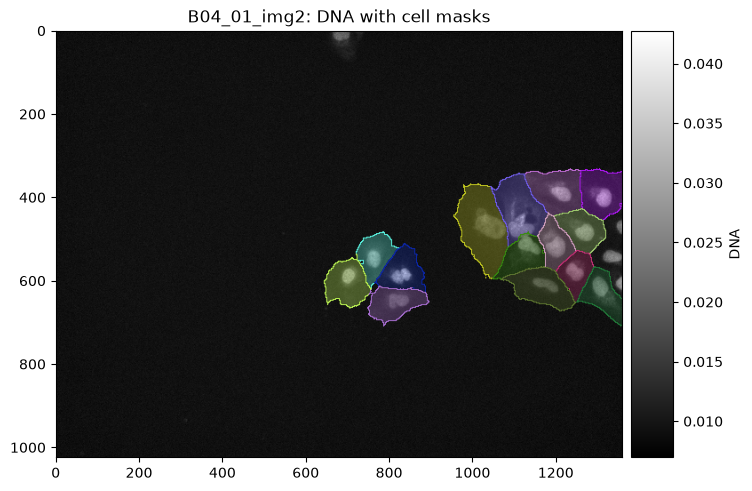

In [9]:
(
    sdata.pl.render_images(image_name(sdata, field), channel=CHANNEL, cmap="gray")
    .pl.render_labels(f"{field}__Cells", fill_alpha=0.3, outline_alpha=1.0)
    .pl.show(coordinate_systems=field, title=f"{field}: {CHANNEL} with cell masks")
)

Then in napari, all three channels and both masks. Toggle the label layers to see the nucleus
inside its cell.

In [10]:
viewer = show_field(sdata, field)

## Colouring cells by a measurement

The join, used rather than asserted. Each cell is painted with its own value of one feature, so a
wrong `region_key` or `label_id` would show up as a scrambled image rather than a gradient that
tracks what you can see in the raw channel. Area is the clearest one to check by eye: big cells
should come out bright.

Note what the names look like. `var_names` are cp_measure names, which drop the CellProfiler
category prefix, so `AreaShape_Area` is exported as `Cells__Area`. Select on `var["category"]`
rather than guessing at the string; `var["cp_name"]` holds the original CellProfiler name.

In [11]:
table = sdata.tables["cells"]
shape_features = table.var.index[table.var["category"].eq("AreaShape")
                                 & table.var["region"].eq("Cells")]
list(shape_features[:10])

['Cells__Extent',
 'Cells__EulerNumber',
 'Cells__EquivalentDiameter',
 'Cells__MajorAxisLength',
 'Cells__MinorAxisLength',
 'Cells__Area',
 'Cells__Perimeter',
 'Cells__MaximumRadius',
 'Cells__MeanRadius',
 'Cells__MedianRadius']

In [12]:
feature = "Cells__Area" if "Cells__Area" in table.var_names else str(shape_features[0])
painted = feature_map(sdata, field, feature)
print(f"{feature}: {np.nanmin(painted):.0f} to {np.nanmax(painted):.0f} px, "
      f"{np.isnan(painted).mean():.1%} of the frame is background")

Cells__Area: 6232 to 18730 px, 90.1% of the frame is background


In [13]:
viewer = show_feature(sdata, field, feature)

## The whole object in napari-spatialdata

`Interactive` gives the coordinate systems, every element, and the table's columns as colourings,
without any of the helpers above. Useful for browsing; the helpers stay because they make what is
being checked explicit.

In [14]:
from napari_spatialdata import Interactive

Interactive(sdata)

2026-09-04 15:33:27.876 | WARNING  | napari_spatialdata._viewer:__init__:56 - Due to Shift-L being used as shortcut in napari, it is being deprecated and might not link a new layer to an existing SpatialData object in the viewer. Please use ⌘-L on MacOS or else Ctrl-L.


## Same table as the AnnData export

Both modules build the table through the same code, so this should be exact. If it ever is not, the
two exports have diverged and the SpatialData object is no longer interchangeable with the AnnData
one.

Row names differ on purpose. `ExportForSpatialData` always appends `img<n>`, because it names files
during the run and rows afterwards, possibly from different processes, and those two have to agree
without being able to check the whole run for uniqueness.

In [15]:
adata = ad.read_h5ad("Testrun_cp2sd_2ad.h5ad")
spatial = sdata.tables["cells"]

print(f"anndata export      {adata.shape}  e.g. {adata.obs_names[0]}")
print(f"spatialdata table   {spatial.shape}  e.g. {spatial.obs_names[0]}")
assert list(adata.var_names) == list(spatial.var_names)
assert np.array_equal(adata.obs["ImageNumber"].to_numpy(int), spatial.obs["ImageNumber"].to_numpy(int))
assert np.array_equal(adata.obs["label_id"].to_numpy(int), spatial.obs["label_id"].to_numpy(int))
assert np.allclose(np.asarray(adata.X), np.asarray(spatial.X), equal_nan=True)
print(f"identical on all {adata.shape[1]} features, same rows in the same order")

anndata export      (151, 126)  e.g. A02_03_1
spatialdata table   (151, 126)  e.g. A02_03_img1_1
identical on all 126 features, same rows in the same order


What the SpatialData table carries on top: `obs["region_key"]` naming each row's mask, and the
`elements` and `image_channels` manifests in `uns["cellprofiler_mapping"]`. Everything else,
including the pipeline provenance in `uns["cellprofiler"]`, is common to both.

In [16]:
print("extra obs columns:", sorted(set(spatial.obs.columns) - set(adata.obs.columns)))
print("extra mapping tables:", sorted(set(spatial.uns["cellprofiler_mapping"])
                                      - set(adata.uns["cellprofiler_mapping"])))

extra obs columns: ['region_key']
extra mapping tables: ['elements', 'image_channels']


## Writing it out

`sdata.write` gives the SpatialData Zarr store, which is the format the rest of the ecosystem
reads. Worth running at least once: the manifest travels inside the table's `uns`, so anything
unwritable in it makes the whole object unwritable, which is how the `dtype` column bug was found.

In [17]:
store = Path("Testrun_cp2sd_2sd_export/plate.zarr")
if not store.exists():
    sdata.write(store)
print(store, "exists:", store.exists())

Testrun_cp2sd_2sd_export/plate.zarr exists: True
